In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RnVwPCB8UgjXPHrFvLlO")
project = rf.workspace("roboflow-jvuqo").project("detecting-vehicles-on-aerial-images")
version = project.version(8)
dataset = version.download("yolov9")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 2.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Detecting-Vehicles-on-Aerial-Images-8 in yolov9:: 100%|██████████| 449/449 [00:00<00:00, 6421.49it/s]


In [2]:
# Define a function to write text to a file
def write_text_to_file(text, file_path):
    with open(file_path, 'w') as file:
        file.write(text)


text="""
names:
- bus
- cars
- truck
- van

nc: 4


train: /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/train/images
val: /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images

"""

write_text_to_file(text, "output.yaml")

In [3]:
%pip install ultralytics
import ultralytics
ultralytics.checks()


Ultralytics 8.3.39 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 5933.9/8062.4 GB disk)


In [4]:
!yolo task=detect  mode=train data=/kaggle/working/output.yaml model=yolov9c.yaml epochs=100 imgsz=640 batch=16

Ultralytics 8.3.39 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov9c.yaml, data=/kaggle/working/output.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, 

In [5]:
from IPython.display import Image, display


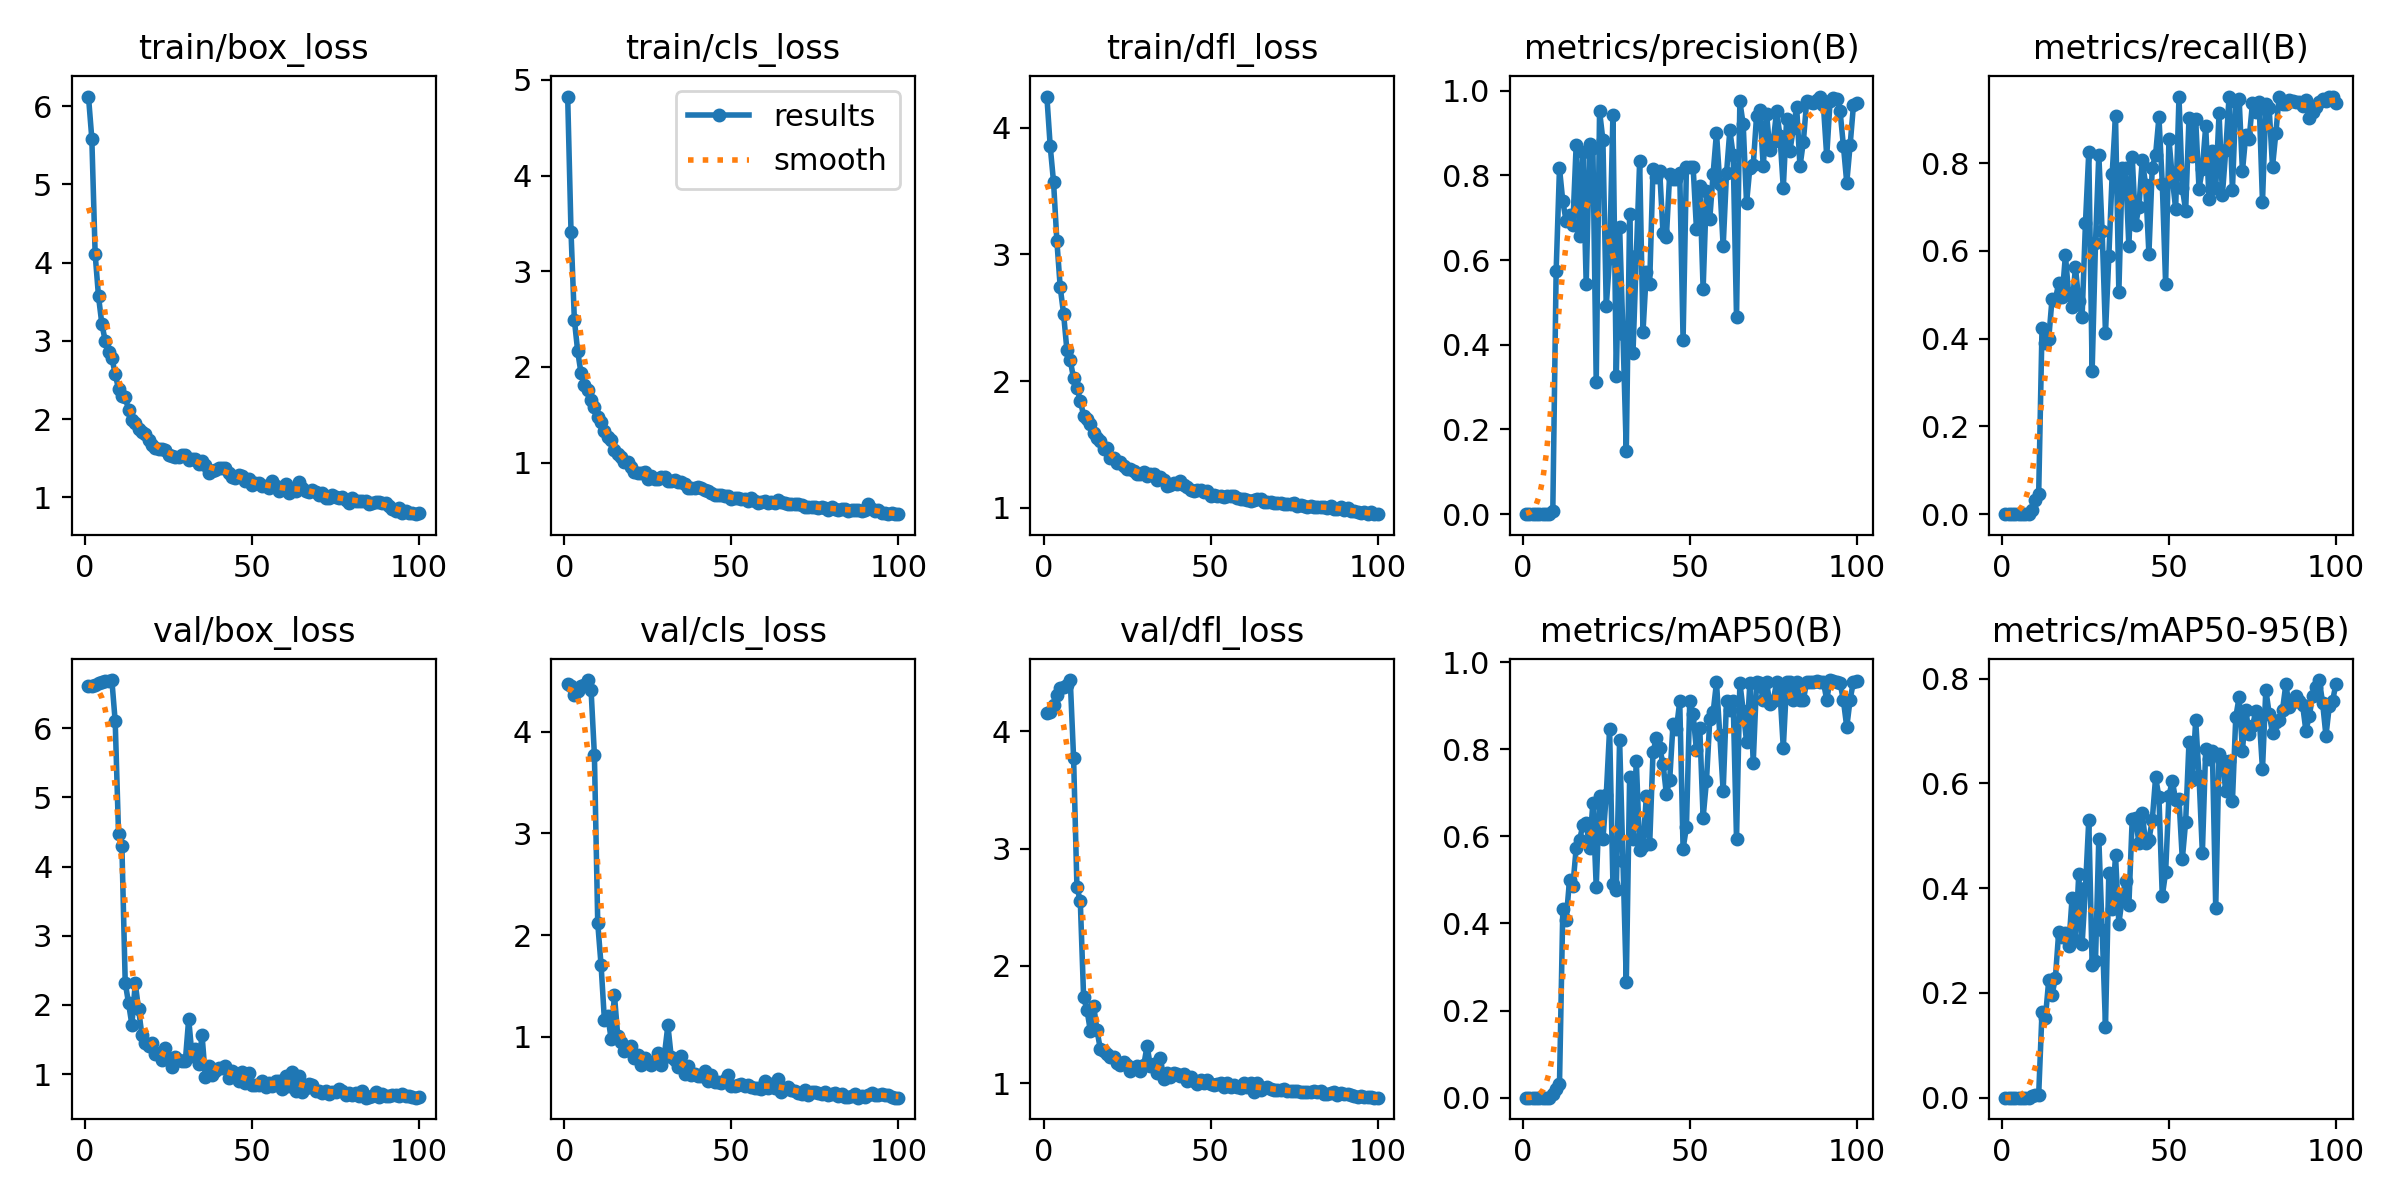

In [6]:
display(Image(filename=f"/kaggle/working/runs/detect/train/results.png", width=1000))

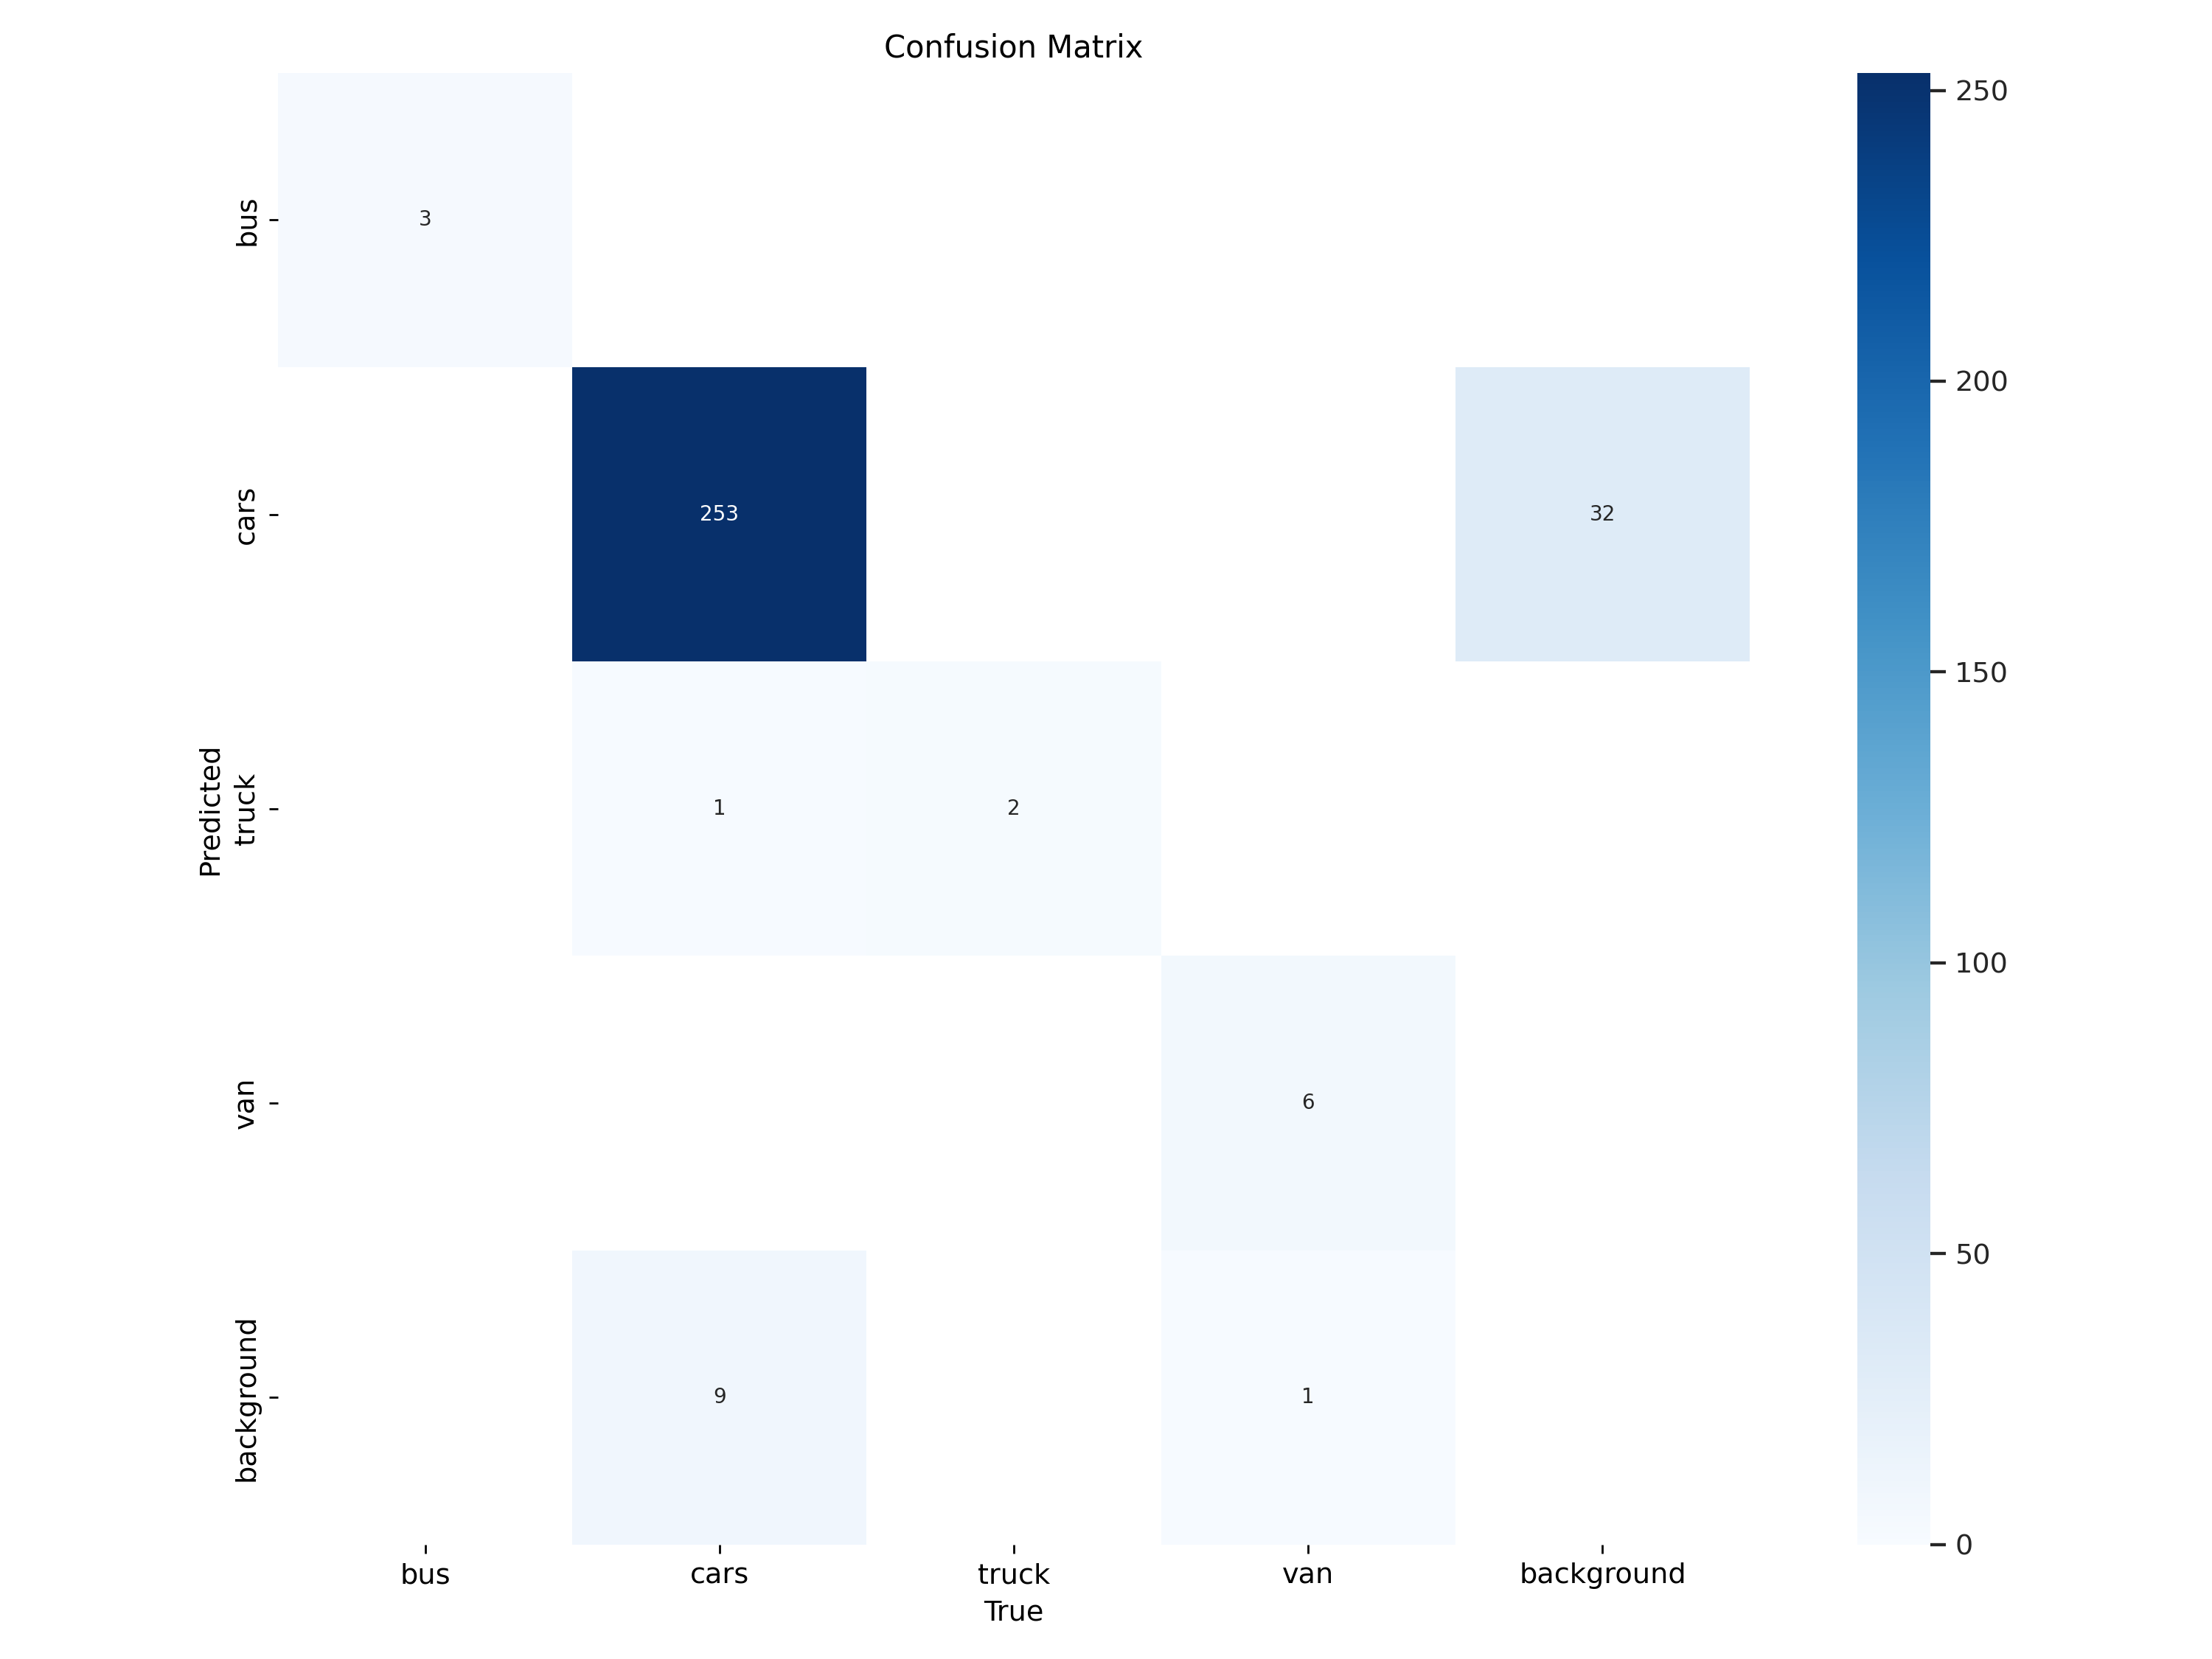

In [7]:
display(Image(filename=f"/kaggle/working/runs/detect/train/confusion_matrix.png", width=1000))

In [8]:
!yolo task=detect mode=predict model=/kaggle/working/runs/detect/train/weights/best.pt imgsz=640 conf=0.5 \
source=/kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images

Ultralytics 8.3.39 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv9c summary (fused): 384 layers, 25,322,332 parameters, 0 gradients, 102.3 GFLOPs

image 1/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.2dfd83456bdab714d17f5dce21f6fb21.jpg: 384x640 6 carss, 57.9ms
image 2/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.57dd1ca4219b2d4bff4124436b668d42.jpg: 384x640 13 carss, 19.2ms
image 3/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.64660ffa4781986d208cae6033175f2a.jpg: 384x640 9 carss, 19.7ms
image 4/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-10_jpg.rf.834eae8f7121c25e9a4153b05c19a544.jpg: 384x640 22 carss, 19.6ms
image 5/16 /kaggle/working/Detecting-Vehicles-on-Aerial-Images-8/valid/images/city-3-11_jpg.rf.474f3f32d026c860cc073dc7bdfd17d7.jpg: 384x640 23 carss, 19.7ms
image 6/16 /kaggle/working/Detecting-

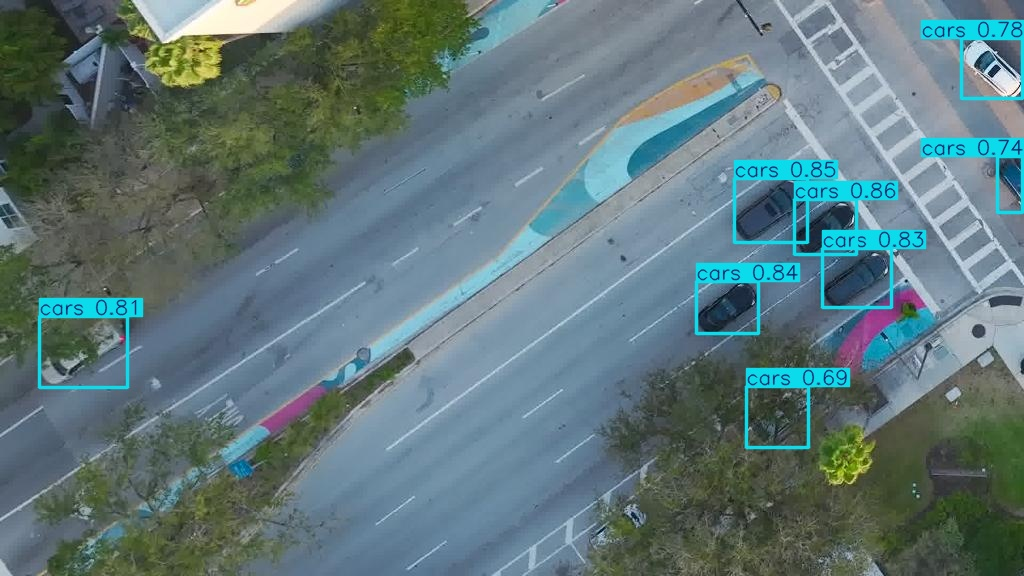

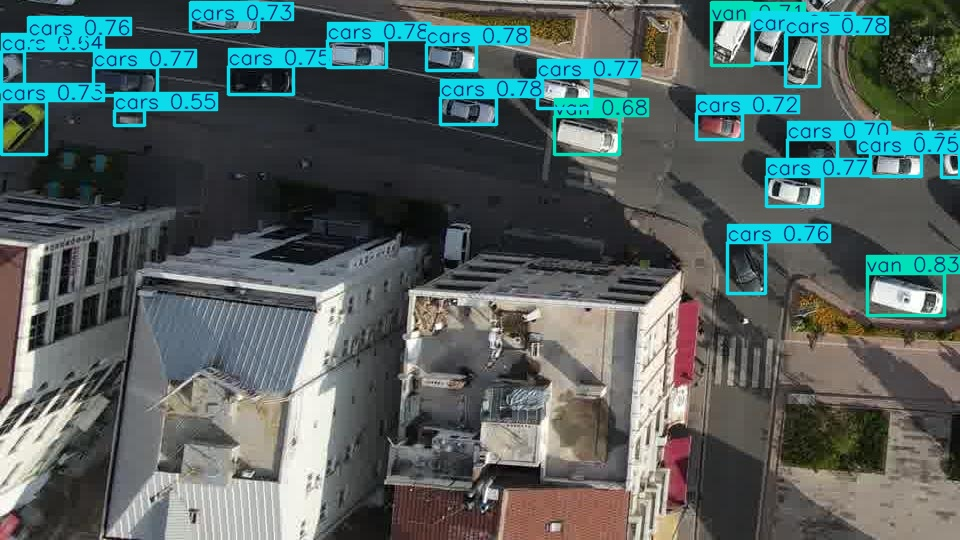

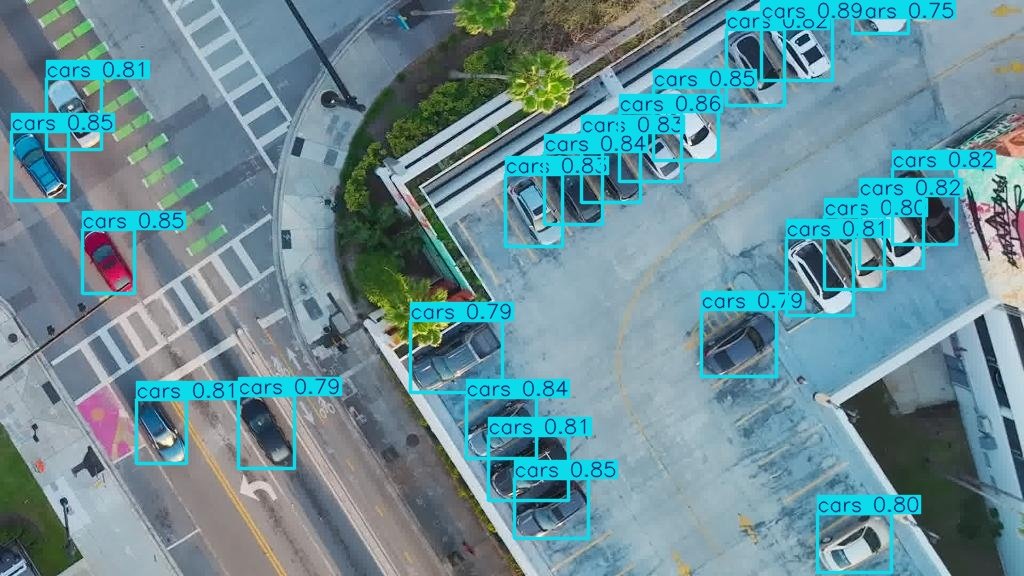

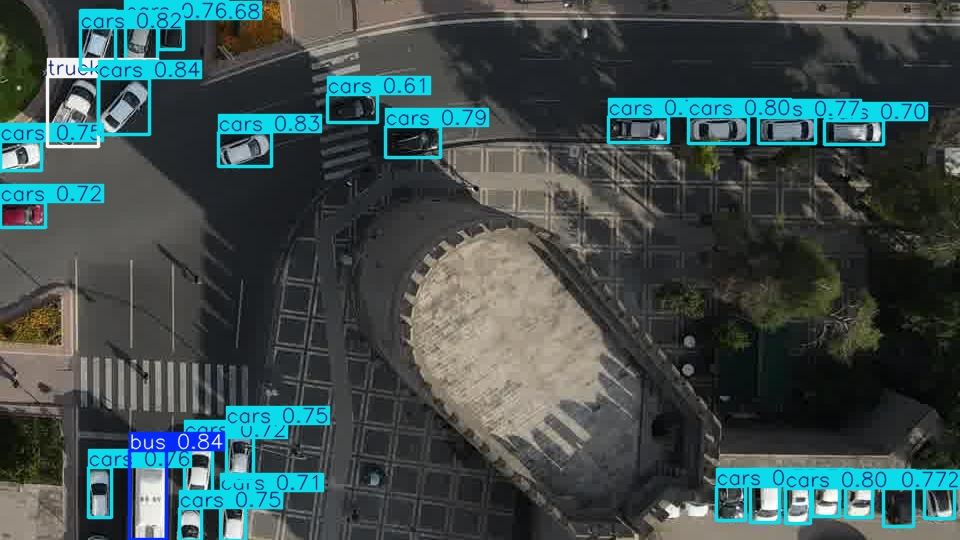

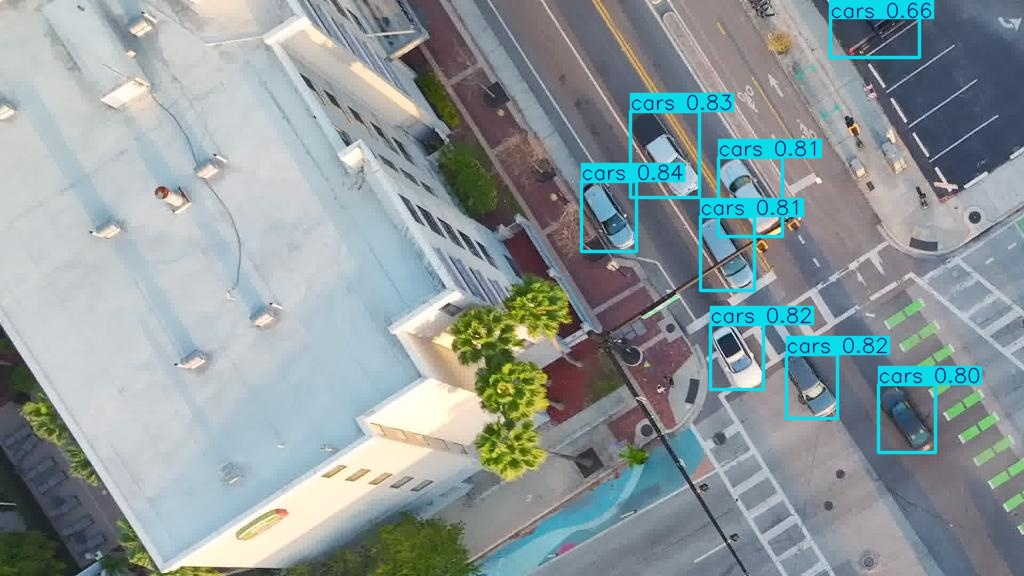

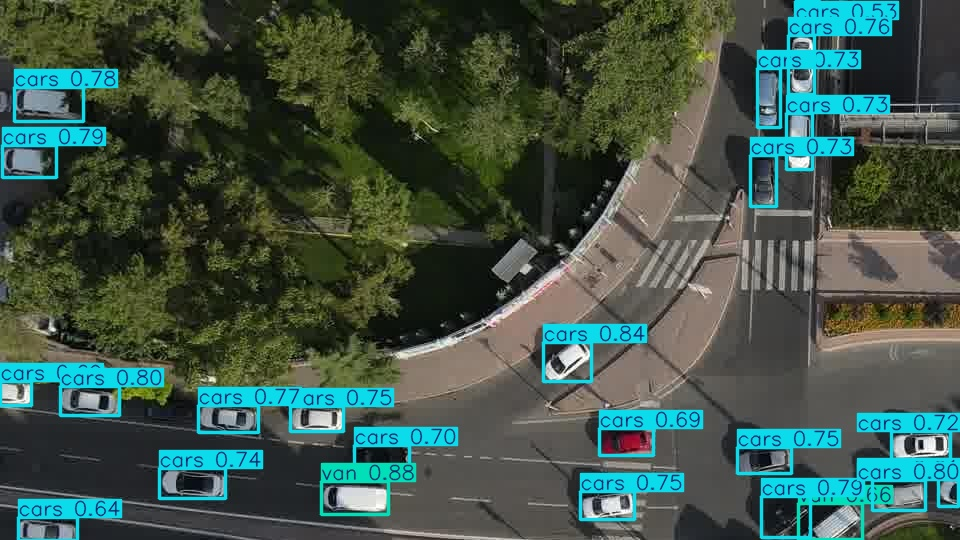

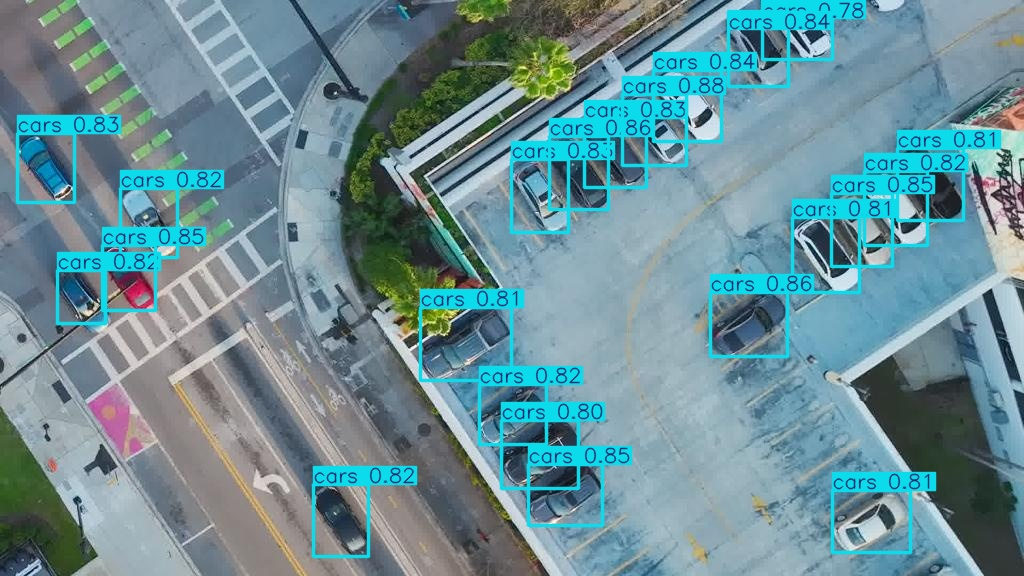

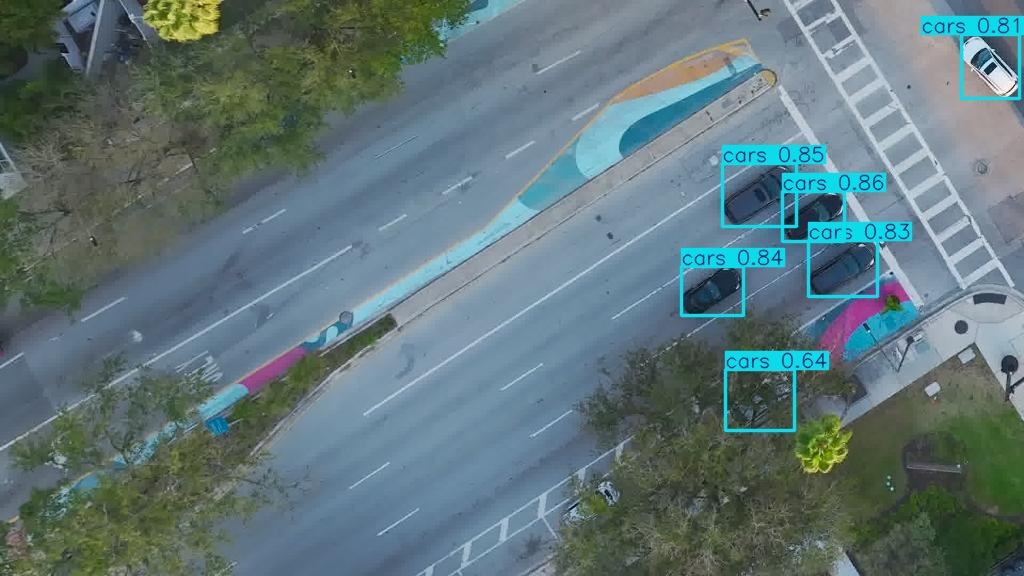

In [9]:
# Display inference on ALL test images
import glob
from IPython.display import Image, display


for imageName in glob.glob("/kaggle/working/runs/detect/predict/*.jpg")[2:10] :#assuming JPG
    print("\n")
    display(Image(filename=imageName))